<a href="https://colab.research.google.com/github/DD-bit001/ML_Projects/blob/main/Cat_vs_Dog_image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_b929527eb7d46bbc3f7c18350571e3e2"

!kaggle competitions list

ref                                                                           deadline             category         reward  teamCount  userHasEntered  
----------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge   2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                            2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                    2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection          2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False  
https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3                  2026-11-02

In [2]:
!kaggle datasets download -d salader/dogsvscats -p /content

Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
License(s): unknown
100% 1.06G/1.06G [00:51<00:00, 22.2MB/s]



In [3]:
import zipfile
import os

zip_ref = zipfile.ZipFile('/content/dogsvscats.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [4]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout
import matplotlib.pyplot as plt
import cv2

In [5]:
##generators provied by generators

In [6]:
# Load the training dataset
train_ds = keras.utils.image_dataset_from_directory(
    directory='/content/train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256)
)

# Load the validation dataset
validation_ds = keras.utils.image_dataset_from_directory(
    directory='/content/test',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [7]:
#Normalise
def process(image, label):
  image = tf.cast(image/255. , tf.float32)
  return image, label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)


Before making changes, let's confirm the class names and their corresponding integer labels as inferred by `image_dataset_from_directory`. This ensures our prediction logic aligns with the model's output.

In [8]:
import os

# The original `train_ds` object, after being modified by `train_ds.map(process)`,
# became a `_MapDataset` which does not have the `label_mode` or `class_names` attributes
# that were present on the object returned by `keras.utils.image_dataset_from_directory`.
# To get the class names, we can infer them from the directory structure as
# `image_dataset_from_directory` does by default.

data_dir = '/content/train'
class_names = sorted([name for name in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, name))])

print('Class Names (0-indexed labels):', class_names)
print('Original label mode for the dataset was inferred as "int".')

Class Names (0-indexed labels): ['cats', 'dogs']
Original label mode for the dataset was inferred as "int".


To address the overfitting issue, I will introduce data augmentation. This technique creates new, altered versions of images from the training dataset, which helps the model learn more robust features and improves generalization.

In [9]:
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal_and_vertical"),
    keras.layers.RandomRotation(0.2),
    keras.layers.RandomZoom(0.2),
    keras.layers.RandomContrast(0.2)
])

In [10]:
#create cnn model

In [11]:
model=Sequential([
    keras.Input(shape=(256,256,3)), # Explicitly define the input shape for the model
    data_augmentation, # This layer will now receive inputs of (256,256,3)
    Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu'), # input_shape is now inferred
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'),

    Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'),

    Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'),

    Flatten(),

    Dense(128,activation='relu'),
    Dropout(0.1),
    Dense(64,activation='relu'),
    Dropout(0.1),
    Dense(1,activation='sigmoid')
])

In [12]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [13]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [14]:
history=model.fit(train_ds,epochs=30,validation_data=validation_ds)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 114s 168ms/step - accuracy: 0.5358 - loss: 1.3202 - val_accuracy: 0.5882 - val_loss: 0.6629
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 107s 171ms/step - accuracy: 0.6025 - loss: 0.6744 - val_accuracy: 0.6426 - val_loss: 0.6236
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 109s 174ms/step - accuracy: 0.6612 - loss: 0.6129 - val_accuracy: 0.6940 - val_loss: 0.5849
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 106s 170ms/step - accuracy: 0.6956 - loss: 0.5842 - val_accuracy: 0.6606 - val_loss: 0.6489
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 105s 169ms/step - accuracy: 0.7021 - loss: 0.5747 - val_accuracy: 0.7038 - val_loss: 0.5728
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 109s 175ms/step - accuracy: 0.7188 - loss: 0.5565 - val_accuracy: 0.7150 - val_loss: 0.5450
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 105s 168ms/step - accuracy: 0.7354 - loss: 0.5311 - val_accuracy: 0.7308 - val_loss: 0.5263
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 105s 168ms/step - accuracy: 0.7456 -

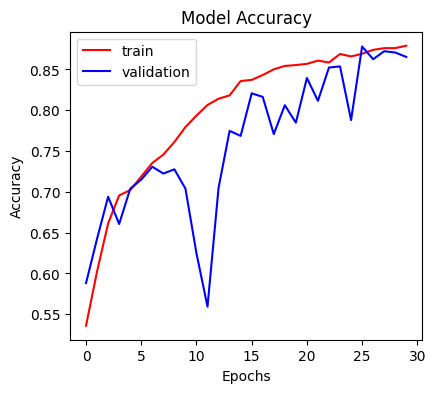

In [15]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()



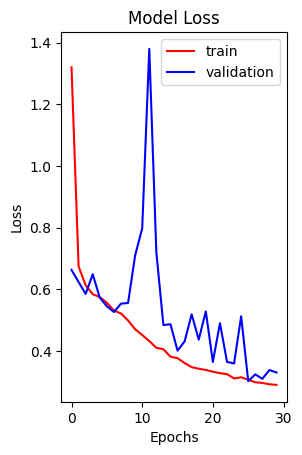

In [16]:
# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [1]:
image_path = '/content/readhead-cat-sitting.jpg' # Changed to a cat image

if os.path.exists(image_path):
    test_img = cv2.imread(image_path)
    # Convert BGR (OpenCV default) to RGB for correct matplotlib plotting
    test_img_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
    plt.imshow(test_img_rgb)
    plt.axis('off')
    plt.show()

    # Preprocess the image to fit model expectations
    test_img_resized = cv2.resize(test_img, (256, 256))
    test_input = test_img_resized.reshape((1, 256, 256, 3))

    # Scale image pixels if the training pipeline scales them
    test_input = test_input / 255.0

    # Prediction
    prediction = model.predict(test_input)
    print(f"Raw Prediction Value: {prediction[0][0]}")

    # Based on the class_names: ['cats', 'dogs'], 0 is cat and 1 is dog.
    if prediction[0][0] < 0.5:
        print("Prediction: It's a cat!")
    else:
        print("Prediction: It's a Dog!")
else:
    print(f"Image not found at {image_path}. Please check your path.")

NameError: name 'os' is not defined

Now, let's evaluate the model's performance on the validation dataset to see the impact of the data augmentation and increased training epochs.

In [18]:
loss, accuracy = model.evaluate(validation_ds)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.8654 - loss: 0.3300
Validation Loss: 0.3300
Validation Accuracy: 0.8654


After evaluating the model, we can assess if the changes helped improve generalization and reduced the tendency to misclassify. Remember that even with improvements, perfect classification might not be achieved, but we should see better overall accuracy and a smaller gap between training and validation metrics if overfitting was reduced.